In [8]:
import numpy as np

def solve_2d_heat_conduction(
    Lx=1.0,
    Ly=1.0,
    Nx=30,
    Ny=30,
    q=1.0,
    k=1.0,
    bc=None
):
    if bc is None:
        bc = {
            "left":   {"type": "Dirichlet", "value": 0.0},
            "right":  {"type": "Dirichlet", "value": 0.0},
            "bottom": {"type": "Dirichlet", "value": 0.0},
            "top":    {"type": "Dirichlet", "value": 0.0},
        }

    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)

    if abs(dx - dy) > 1e-12:
        raise ValueError("This first version assumes dx = dy.")

    h = dx
    N = Nx * Ny

    A = np.zeros((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return i * Ny + j

    def is_boundary(i, j):
        return i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1

    def get_boundary_side(i, j):
        if i == 0:
            return "bottom"
        elif i == Nx - 1:
            return "top"
        elif j == 0:
            return "left"
        elif j == Ny - 1:
            return "right"
        else:
            return None

    for i in range(Nx):
        for j in range(Ny):

            p = idx(i, j)

            if is_boundary(i, j):
                side = get_boundary_side(i, j)
                bc_type = bc[side]["type"]
                bc_value = bc[side]["value"]

                if bc_type == "Dirichlet":
                    A[p, p] = 1.0
                    b[p] = bc_value
                else:
                    raise NotImplementedError("Only Dirichlet BCs are implemented for now.")

            else:
                A[p, idx(i, j)] = -4.0
                A[p, idx(i + 1, j)] = 1.0
                A[p, idx(i - 1, j)] = 1.0
                A[p, idx(i, j + 1)] = 1.0
                A[p, idx(i, j - 1)] = 1.0

                b[p] = -(q / k) * h**2

    T_vector = np.linalg.solve(A, b)
    T = T_vector.reshape((Nx, Ny))

    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)

    return x, y, T, A, b

In [9]:
bc = {
    "left":   {"type": "Dirichlet", "value": 0.0},
    "right":  {"type": "Dirichlet", "value": 0.0},
    "bottom": {"type": "Dirichlet", "value": 0.0},
    "top":    {"type": "Dirichlet", "value": 100.0},
}

x, y, T, A, b = solve_2d_heat_conduction(
    Lx=1.0,
    Ly=1.0,
    Nx=30,
    Ny=30,
    q=1.0,
    k=1.0,
    bc=bc
)

print("Maximum temperature:", np.max(T))

Maximum temperature: 100.0


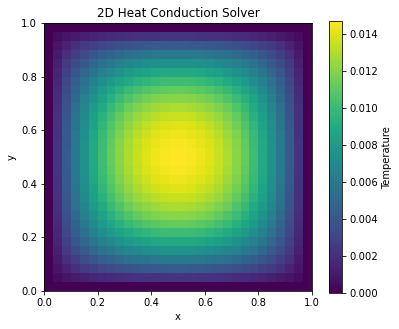

Maximum temperature: 0.01469079950914327
Minimum temperature: 0.0
Matrix size: (900, 900)


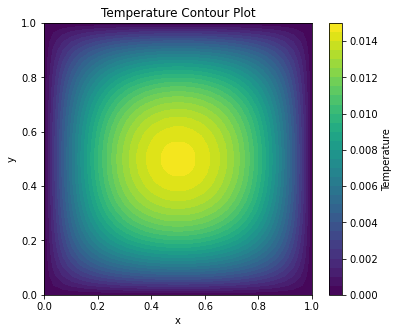

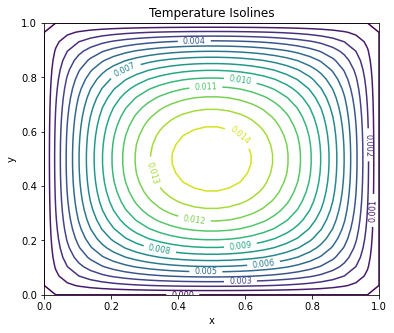

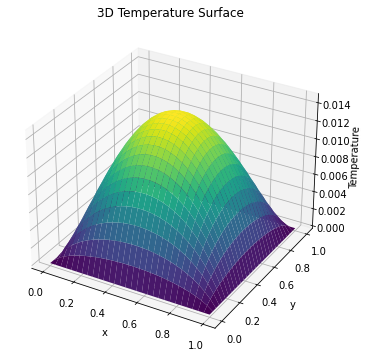

In [29]:
# -----------------------
# Plot
# -----------------------

plt.figure(figsize=(6, 5))

plt.imshow(
    T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Heat Conduction Solver")
plt.savefig("temperature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Maximum temperature:", np.max(T))
print("Minimum temperature:", np.min(T))
print("Matrix size:", A.shape)

plt.figure(figsize=(6,5))

X = np.linspace(0, Lx, Nx)
Y = np.linspace(0, Ly, Ny)

plt.contourf(
    X,
    Y,
    T,
    levels=30
)

plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Temperature Contour Plot")
plt.savefig("temperature_contours.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,5))

contours = plt.contour(
    X,
    Y,
    T,
    levels=15
)

plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Temperature Isolines")

plt.show()

from mpl_toolkits.mplot3d import Axes3D

X = np.linspace(0, Lx, Nx)
Y = np.linspace(0, Ly, Ny)

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X_grid,
    Y_grid,
    T,
    cmap="viridis"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Temperature")
ax.set_title("3D Temperature Surface")
plt.savefig("temperature_surface.png", dpi=300, bbox_inches="tight")
plt.show()

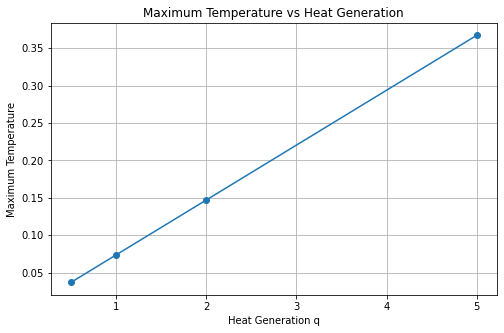

In [27]:
#q variation study
bc = {
    "left":   {"type": "Dirichlet", "value": 0.0},
    "right":  {"type": "Dirichlet", "value": 0.0},
    "bottom": {"type": "Dirichlet", "value": 0.0},
    "top":    {"type": "Dirichlet", "value": 0.0},
}
q_values = [0.5, 1.0, 2.0, 5.0]
max_temperatures = []

for q in q_values:

    x, y, T, A, b = solve_2d_heat_conduction(
        Lx=1.0,
        Ly=1.0,
        Nx=30,
        Ny=30,
        q=q,
        k=1.0,
        bc=bc
    )

    max_temperatures.append(np.max(T))

plt.figure(figsize=(8,5))
plt.plot(q_values, max_temperatures, "o-")

plt.xlabel("Heat Generation q")
plt.ylabel("Maximum Temperature")
plt.title("Maximum Temperature vs Heat Generation")
plt.grid(True)

plt.show()

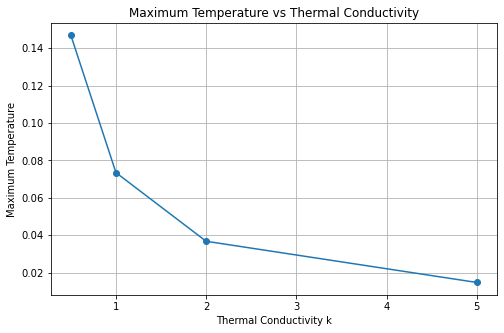

In [28]:
k_values = [0.5, 1.0, 2.0, 5.0]
max_temperatures = []

for k in k_values:

    x, y, T, A, b = solve_2d_heat_conduction(
        Lx=1.0,
        Ly=1.0,
        Nx=30,
        Ny=30,
        q=1.0,
        k=k,
        bc=bc
    )

    max_temperatures.append(np.max(T))

plt.figure(figsize=(8,5))
plt.plot(k_values, max_temperatures, "o-")

plt.xlabel("Thermal Conductivity k")
plt.ylabel("Maximum Temperature")
plt.title("Maximum Temperature vs Thermal Conductivity")
plt.grid(True)
plt.savefig("temperature_vs_conductivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def solve_2d_heat_conduction_sparse(
    Lx=1.0,
    Ly=1.0,
    Nx=30,
    Ny=30,
    q=1.0,
    k=1.0,
    bc=None
):
    if bc is None:
        bc = {
            "left":   {"type": "Dirichlet", "value": 0.0},
            "right":  {"type": "Dirichlet", "value": 0.0},
            "bottom": {"type": "Dirichlet", "value": 0.0},
            "top":    {"type": "Dirichlet", "value": 0.0},
        }

    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)

    if abs(dx - dy) > 1e-12:
        raise ValueError("This version assumes dx = dy.")

    h = dx
    N = Nx * Ny

    A = lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return i * Ny + j

    def is_boundary(i, j):
        return i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1

    def get_boundary_side(i, j):
        if i == 0:
            return "bottom"
        elif i == Nx - 1:
            return "top"
        elif j == 0:
            return "left"
        elif j == Ny - 1:
            return "right"
        else:
            return None

    for i in range(Nx):
        for j in range(Ny):

            p = idx(i, j)

            if is_boundary(i, j):
                side = get_boundary_side(i, j)
                bc_type = bc[side]["type"]
                bc_value = bc[side]["value"]

                if bc_type == "Dirichlet":
                    A[p, p] = 1.0
                    b[p] = bc_value
                else:
                    raise NotImplementedError("Only Dirichlet BCs are implemented for now.")

            else:
                A[p, p] = -4.0
                A[p, idx(i + 1, j)] = 1.0
                A[p, idx(i - 1, j)] = 1.0
                A[p, idx(i, j + 1)] = 1.0
                A[p, idx(i, j - 1)] = 1.0

                b[p] = -(q / k) * h**2

    A = A.tocsr()

    T_vector = spsolve(A, b)

    T = T_vector.reshape((Nx, Ny))

    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)

    return x, y, T, A, b

In [20]:
#Compare dense and sparse matrix
bc = {
    "left":   {"type": "Dirichlet", "value": 0.0},
    "right":  {"type": "Dirichlet", "value": 0.0},
    "bottom": {"type": "Dirichlet", "value": 0.0},
    "top":    {"type": "Dirichlet", "value": 100.0},
}

x, y, T_sparse, A, b = solve_2d_heat_conduction_sparse(
    Nx=30,
    Ny=30,
    q=1.0,
    k=1.0,
    bc=bc
)

x, y, T_dense, A, b = solve_2d_heat_conduction(
    Nx=30,
    Ny=30,
    q=1.0,
    k=1.0,
    bc=bc
)
np.max(np.abs(T_dense - T_sparse))



2.2026824808563106e-13

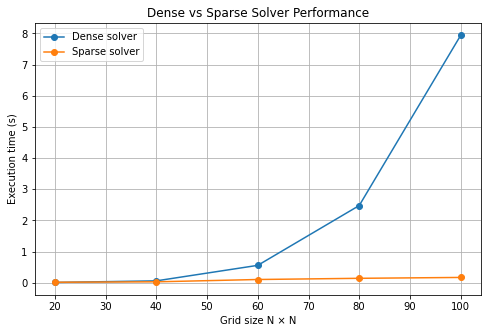

Matrix shape: (10000, 10000)
Non-zero entries: 48416
Density: 0.00048416


In [25]:
#Comparo rendimiento
import time

mesh_sizes = [20, 40, 60, 80, 100]

dense_times = []
sparse_times = []

for N in mesh_sizes:

    start = time.time()
    x, y, T_dense, A_dense, b_dense = solve_2d_heat_conduction(
        Nx=N,
        Ny=N,
        q=1.0,
        k=1.0,
        bc=bc
    )
    dense_times.append(time.time() - start)

    start = time.time()
    x, y, T_sparse, A_sparse, b_sparse = solve_2d_heat_conduction_sparse(
        Nx=N,
        Ny=N,
        q=1.0,
        k=1.0,
        bc=bc
    )
    sparse_times.append(time.time() - start)

plt.figure(figsize=(8,5))

plt.plot(mesh_sizes, dense_times, "o-", label="Dense solver")
plt.plot(mesh_sizes, sparse_times, "o-", label="Sparse solver")

plt.xlabel("Grid size N × N")
plt.ylabel("Execution time (s)")
plt.title("Dense vs Sparse Solver Performance")
plt.legend()
plt.grid(True)
plt.savefig("dense_vs_sparse_solver.png", dpi=300, bbox_inches="tight")
plt.show()

print("Matrix shape:", A_sparse.shape)
print("Non-zero entries:", A_sparse.nnz)
print("Density:", A_sparse.nnz / (A_sparse.shape[0] * A_sparse.shape[1]))

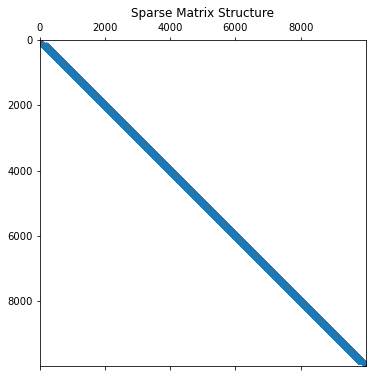

In [23]:
plt.figure(figsize=(6,6))
plt.spy(A_sparse, markersize=1)
plt.title("Sparse Matrix Structure")
plt.savefig("sparse_matrix_structure.png", dpi=300)
plt.show()

In [24]:
total_entries = A_sparse.shape[0] * A_sparse.shape[1]
nonzero_entries = A_sparse.nnz

print(f"Total entries      : {total_entries:,}")
print(f"Non-zero entries  : {nonzero_entries:,}")
print(f"Sparsity          : {100*(1-nonzero_entries/total_entries):.4f}%")
print(f"Density           : {100*nonzero_entries/total_entries:.4f}%")

Total entries      : 100,000,000
Non-zero entries  : 48,416
Sparsity          : 99.9516%
Density           : 0.0484%
